# bAsedPL

bAsedPL ("Based-array APL") is an APL-derived array language, borrowing ideas from J and BQN, with an emphasis on simple, consistent notation. It is implemented in Rust, with a native executable, Jupyter kernel and Python API.

For APL users, the main choices are:

- [Based arrays](https://answerdotai.github.io/basedpl/rules.html#arrays-nesting-and-fill), as in BQN: numbers, characters and functions are atoms; enclosure always adds a layer.
- **Leading-axis broadcasting**, including unit-axis expansion, plus string keys and names on axes.
- **Exact integers and rationals** alongside approximate real and complex numbers.
- Dfns, trains and operators, with additions such as Under, iteration histories, windows and function arrays.

Indices start at 1; approximate comparisons use tolerance `1E¯14`. See the [glyph reference](https://answerdotai.github.io/basedpl/glyphs.html) for Dyalog differences and the [language rules](https://answerdotai.github.io/basedpl/rules.html) for the array model.

## Install and try it

```sh
pip install basedpl
bapl
```

At the prompt, define a mean and apply it:

In [ ]:
avg←+/÷≢
avg 2 4 9

5

Use `bapl -e 'avg←+/÷≢ ⋄ avg 2 4 9'` for a shell command. The [command-line guide](https://answerdotai.github.io/basedpl/cli.html) covers source files and pipes.

## Interactive use

In the **REPL**, type a backtick followed by a glyph name: `` `iota `` becomes `⍳` when you press Tab or type a non-letter. Abbreviations and Alt-key shortcuts are available. `]help +` shows help; `]box on -style=max -trains=tree -fns=on` enables boxed arrays and function trees. See [REPL](https://answerdotai.github.io/basedpl/repl.html) and [Keyboard](https://answerdotai.github.io/basedpl/keyboard.html).

In **Jupyter**, select the installed **bAsedPL** kernel. Cells share definitions and support completion, Shift-Tab help and interruption. You can also use `%%apl` cells in a Python notebook. See [Using bAsedPL notebooks](https://answerdotai.github.io/basedpl/notebooks.html).

## New to APL?

APL is a language built around operations on whole arrays and notation for combining functions. Here is a taste of that style in bAsedPL.

Spaces form a vector. Arithmetic applies to every element:

In [ ]:
10+1 2 3

11 12 13

Operators modify or combine functions. Reduce (`/`) turns addition into summation; `⍳10` generates 1…10:

In [ ]:
+/⍳10

55

Functions can also be combined without naming their arguments. In `avg←+/÷≢`, sum (`+/`) divided by tally (`≢`) defines the mean:

In [ ]:
avg 1 2 3 4

2.5

To see how these ideas express an algorithm, start from “a prime has exactly two positive divisors”. Form all remainders (`|⌝⍨`), count the zeros down each column (`+⌿0=`), and find the positions (`⍸`) whose count is two:

In [ ]:
⍸2=+⌿0=|⌝⍨⍳50

2ₓ 3ₓ 5ₓ 7ₓ 11ₓ 13ₓ 17ₓ 19ₓ 23ₓ 29ₓ 31ₓ 37ₓ 41ₓ 43ₓ 47ₓ

[Getting started](https://answerdotai.github.io/basedpl/getting-started.html#example-algorithms) builds this expression step by step, displaying the divisibility matrix along the way.

## What's distinctive?

### Numbers

Bare numbers are approximate. Use `x` for exact integers and `r` for exact fractions:

In [ ]:
1r3+1r6

1r2

Complex numbers use `j` between real and imaginary parts. Functions such as square root extend into the complex domain:

In [ ]:
√¯4

0j2

See [numbers](https://answerdotai.github.io/basedpl/rules.html#numbers) for conversion and mixed arithmetic.

### Array literals and broadcasting

Write matrix rows directly in an array literal. Leading-axis agreement lets a vector supply one offset per row:

In [ ]:
m←[1 2 3 ⋄ 4 5 6]
m+10 20

11 12 13
24 25 26

See [array notation](https://answerdotai.github.io/basedpl/glyphs/brackets.html) and [broadcasting](https://answerdotai.github.io/basedpl/rules.html#agreement-and-pervasion).

### Keys and named axes

Axes can have names, and positions along them can have string keys. Describe the axes once, then select by key or reduce by axis name:

In [ ]:
axes←('city':'London' 'Paris' ⋄ 'month':'Jan' 'Feb' 'Mar')
sales←axes:[10 20 30 ⋄ 40 50 60]
sales['Paris';'Feb']
+/['month']sales

50

('London':60 ⋄ 'Paris':150)

Keys and names travel with axes through operations such as transpose. Arithmetic aligns matching names and keys. See [Axis keys](https://answerdotai.github.io/basedpl/keyed.html).

### Function operators

Enclose an iteration count to keep the history, including the initial value. Here, double four times:

In [ ]:
(2∘×)⍣[4]⊢1

1 2 4 8 16

Under (`⌾`) transforms the argument, applies a function, then reverses the transformation. Scale by ten, floor, and scale back to round down to tenths:

In [ ]:
⌊⌾(10∘×)⊢1.25 2.78

1.2 2.7

Explore [iteration and inverses](https://answerdotai.github.io/basedpl/glyphs/power.html), [Under](https://answerdotai.github.io/basedpl/glyphs/under.html), [windows](https://answerdotai.github.io/basedpl/glyphs/windows.html) and [function selection](https://answerdotai.github.io/basedpl/glyphs/agenda.html).

### Mathematical tools

[Primes](https://answerdotai.github.io/basedpl/glyphs/prime.html) and [factorisation](https://answerdotai.github.io/basedpl/glyphs/factor.html) are built in:

In [ ]:
⨸360x

2ₓ 2ₓ 2ₓ 3ₓ 3ₓ 5ₓ

[Polynomials](https://answerdotai.github.io/basedpl/glyphs/polynomial.html) support coefficients, roots and evaluation. Polynomial functions can be [differentiated](https://answerdotai.github.io/basedpl/glyphs/derivative.html): for f(x) = 1 + 2x + 3x², f′(2) = 14.

In [ ]:
f←1x 2x 3x∘⊛ ⋄ f∂2x

14ₓ

[Probability distributions](https://answerdotai.github.io/basedpl/distributions.html) provide sampling, density, CDF and quantiles. Two fair coin tosses give these probabilities for 0, 1 and 2 heads:

In [ ]:
coin←•binomial 2 0.5
coin.density 0 1 2

0.25 0.5 0.25

[Matrix division](https://answerdotai.github.io/basedpl/glyphs/domino.html) handles linear systems and least squares.

### Data and text

JSON objects become keyed arrays, with dot access to their fields:

In [ ]:
order←•json '{"price":10.5,"qty":2}'
order.price×order.qty

21

CSV headers likewise name column vectors. [Files, CSV and JSON](https://answerdotai.github.io/basedpl/data.html) covers reading, transforming and writing data. [Regex](https://answerdotai.github.io/basedpl/regex.html) supplies matching, captures and replacement through Rust's regex engine.

### Drawing

`•plot` draws charts from arrays. Keys label the axes and name the lines. See [Plots](https://answerdotai.github.io/basedpl/plot.html).

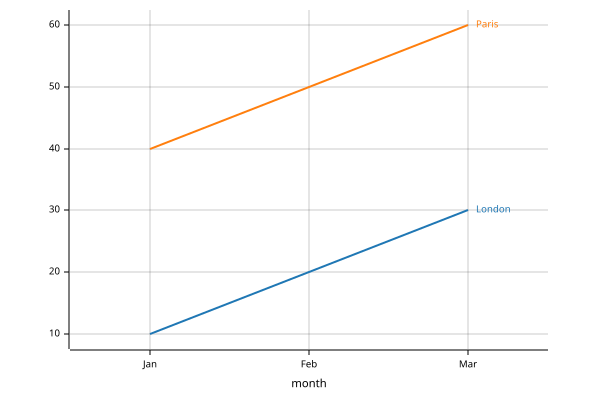

In [ ]:
('legend':'end') •plot ('city':'London' 'Paris' ⋄ 'month':'Jan' 'Feb' 'Mar'):[10 20 30 ⋄ 40 50 60]

Build SVG from element functions and keyed attributes. Notebooks display the picture directly. The same element trees serialize to XML. See [XML and SVG](https://answerdotai.github.io/basedpl/xml.html).

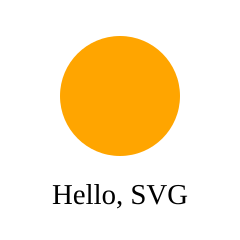

In [ ]:
circle←•element 'circle'
text←•element 'text'
c←('cx':50 ⋄ 'cy':40 ⋄ 'r':25 ⋄ 'fill':'orange') circle ''
t←('x':50 ⋄ 'y':85 ⋄ 'text-anchor':'middle') text 'Hello, SVG'
('width':240 ⋄ 'height':240) •svg (c ⋄ t)

## Python

APL functions are Python callables:

```python
from basedpl import fn

mean = fn('+/÷≢')
mean([1, 2, 3])
```

Arrays have `.py`, `.np` and `.df` conversions for Python values, NumPy and pandas. Functions also have Python names and composition operators. See the [Python tutorial](https://answerdotai.github.io/basedpl/python.html).

For other frontends, the [process interfaces](https://answerdotai.github.io/basedpl/processes.html) provide JSON messages and interruptible workers. The [APL library](https://github.com/AnswerDotAI/basedpl/tree/main/lib) contains more algorithms, codecs, interpreters and puzzles. See [DEV.md](https://github.com/AnswerDotAI/basedpl/blob/main/DEV.md) for source installation and contributing.